<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/Monte_Carlo_Simulation_for_Superconducting_Phase_Prediction_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x

Initializing simulation utilizing backend architecture GPU
Executing deterministic TDGL relaxation at 0.6 K...


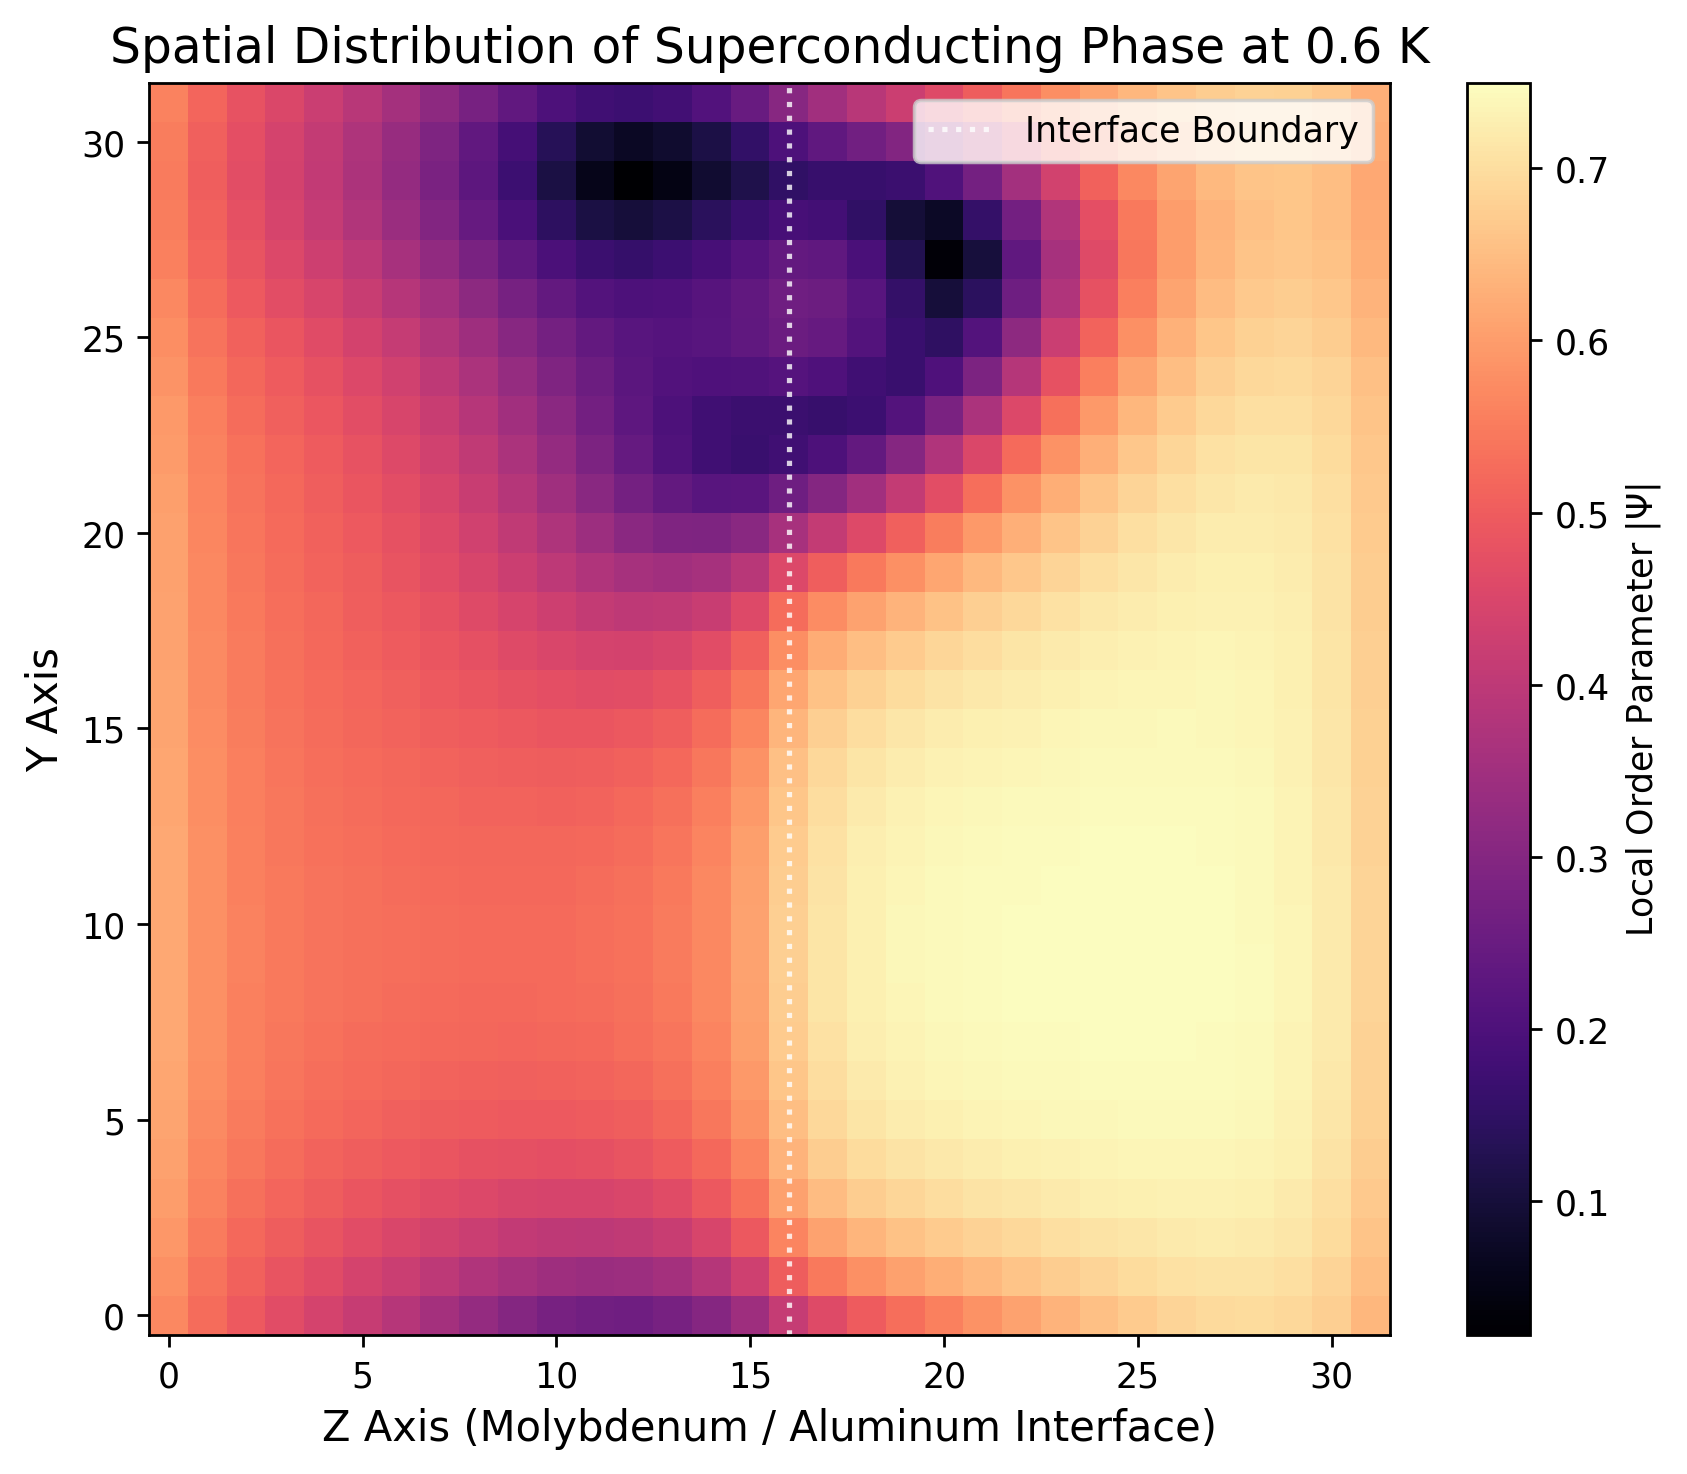


Macroscopic phase evaluation and spatial rendering successfully completed.


In [7]:
"""This script simulates the superconducting transition using deterministic gradient relaxation.

The architecture evaluates a continuous Time Dependent Ginzburg and Landau
equation to strictly enforce macroscopic phase coherence across the simulated
bilayer geometry while entirely bypassing stochastic geometric fragmentation.
"""

import math
from typing import Tuple, List

try:
    import cupy as xp
    _test_allocation = xp.array([1.0])
    DEVICE_TYPE = "GPU"
except Exception:
    import numpy as xp
    DEVICE_TYPE = "CPU"

import matplotlib.pyplot as plt
import matplotlib as mpl

# Global typographical configurations for scientific visualization
mpl.rcParams['figure.dpi'] = 250
mpl.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
mpl.rcParams['font.weight'] = 'normal'

# =============================================================================
# Global Control Knobs
# =============================================================================
LATTICE_DIMENSIONS: Tuple[int, int, int] = (32, 32, 32)
T_INTRINSIC_MO: float = 0.9
T_INTRINSIC_AL: float = 1.18
GL_BETA_COEFF: float = 1.0
GL_GAMMA_COEFF: float = 2.0
RELAXATION_TIME_STEP: float = 0.01
HEATMAP_TARGET_TEMP: float = 0.6
TOTAL_RELAXATION_ITERATIONS: int = 4000
# =============================================================================

class BilayerSuperconductorSim:
    """Simulates the superconducting phase transition using a deterministic TDGL equation.

    Attributes:
        shape (Tuple[int, int, int]): Dimensions of the three dimensional simulation lattice.
        t_mo (float): Intrinsic critical temperature of the Molybdenum layer.
        t_al (float): Intrinsic critical temperature of the Aluminum layer.
        beta (float): The quartic coefficient of the macroscopic free energy.
        gamma (float): The stiffness coefficient for the spatial gradient term.
        xp (module): The active hardware agnostic numerical backend module.
    """

    def __init__(
        self,
        shape: Tuple[int, int, int] = LATTICE_DIMENSIONS,
        t_mo: float = T_INTRINSIC_MO,
        t_al: float = T_INTRINSIC_AL,
        beta: float = GL_BETA_COEFF,
        gamma: float = GL_GAMMA_COEFF
    ):
        """Initializes the thermodynamic parameters and generates the continuous complex field."""
        self.shape = shape
        self.t_mo = t_mo
        self.t_al = t_al
        self.beta = beta
        self.gamma = gamma
        self.xp = xp

        real_part = self.xp.random.randn(*shape).astype(self.xp.float64)
        imag_part = self.xp.random.randn(*shape).astype(self.xp.float64)
        self.psi = (real_part + 1j * imag_part) * 0.1

        self.mid_z = shape[2] // 2

    def _calculate_local_alpha(self, current_t: float) -> xp.ndarray:
        """Calculates the temperature dependent alpha coefficient across the metallic interface."""
        alpha = self.xp.zeros(self.shape, dtype=self.xp.float64)
        alpha[:, :, :self.mid_z] = (current_t - self.t_mo)
        alpha[:, :, self.mid_z:] = (current_t - self.t_al)
        return alpha

    def run_tdgl_relaxation(self, current_t: float, dt: float, iterations: int):
        """Performs deterministic gradient descent updates to strictly minimize free energy."""
        alpha = self._calculate_local_alpha(current_t)

        for _ in range(iterations):
            continuous_laplacian = (
                self.xp.roll(self.psi, 1, axis=0) + self.xp.roll(self.psi, -1, axis=0) +
                self.xp.roll(self.psi, 1, axis=1) + self.xp.roll(self.psi, -1, axis=1) +
                self.xp.roll(self.psi, 1, axis=2) + self.xp.roll(self.psi, -1, axis=2) -
                6.0 * self.psi
            )

            free_energy_derivative = (
                alpha * self.psi +
                self.beta * (self.xp.abs(self.psi)**2) * self.psi -
                self.gamma * continuous_laplacian
            )

            self.psi = self.psi - dt * free_energy_derivative

    def get_spatial_slice(self) -> xp.ndarray:
        """Extracts a central two dimensional planar cross section of the order parameter."""
        mid_x = self.shape[0] // 2
        slice_2d = self.xp.abs(self.psi[mid_x, :, :])

        if hasattr(slice_2d, 'get'):
            return slice_2d.get()
        return slice_2d

def analyze_and_visualize() -> None:
    """Executes the thermodynamic simulation utilizing a deterministic relaxation protocol."""
    print(f"Initializing simulation utilizing backend architecture {DEVICE_TYPE}")
    sim = BilayerSuperconductorSim()

    print(f"Executing deterministic TDGL relaxation at {HEATMAP_TARGET_TEMP} K...")
    sim.run_tdgl_relaxation(
        current_t=HEATMAP_TARGET_TEMP,
        dt=RELAXATION_TIME_STEP,
        iterations=TOTAL_RELAXATION_ITERATIONS
    )

    spatial_data = sim.get_spatial_slice()

    plt.figure(figsize=(7, 6))
    plt.imshow(spatial_data, cmap='magma', origin='lower', aspect='auto')
    plt.colorbar(label=r'Local Order Parameter $|\Psi|$')
    plt.title(f'Spatial Distribution of Superconducting Phase at {HEATMAP_TARGET_TEMP} K', fontsize=14)
    plt.xlabel('Z Axis (Molybdenum / Aluminum Interface)', fontsize=12)
    plt.ylabel('Y Axis', fontsize=12)
    plt.axvline(x=LATTICE_DIMENSIONS[2] // 2, color='white', linestyle=':', alpha=0.8, label='Interface Boundary')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_and_visualize()
    print("\nMacroscopic phase evaluation and spatial rendering successfully completed.")